In [91]:
# ===== Packages =====

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation, RandomContrast
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [21]:
# ===== Manage and Lock Kaggle Key =====

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [27]:
# ===== Check if Locked =====

# (Look for -rw----------)
!ls -l ~/.kaggle

total 4
-rw------- 1 root root 84 Mar 30 02:32 kaggle.json


In [22]:
# ===== Import Data (Kaggle) =====

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:25<00:00, 96.1MB/s]

Archive:  chest-xray-pneumonia.zip
replace chest_xray/__MACOSX/._chest_xray? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace chest_xray/__MACOSX/chest_xray/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
chest_xray  chest-xray-pneumonia.zip  kaggle.json  sample_data


In [28]:
# ===== Dataset Contents =====

!ls /content
!ls /content/chest_xray

chest_xray  chest-xray-pneumonia.zip  kaggle.json  sample_data
chest_xray  __MACOSX  test  train  val


In [30]:
# ===== Separate Folder Contents =====

BASE_DIR = "/content/chest_xray/chest_xray"

train_dir = BASE_DIR + "/train"
test_dir = BASE_DIR + "/test"
val_dir = BASE_DIR + "/val"

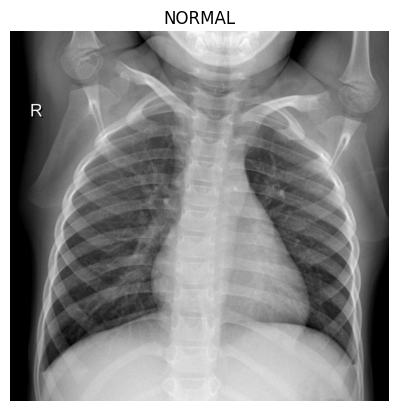

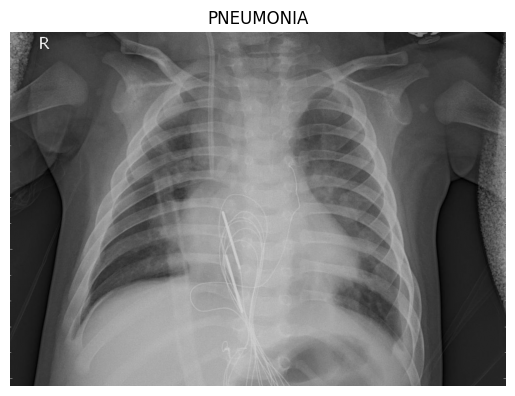

In [33]:
# ===== Validate Images =====

DATADIR = train_dir
CATEGORIES = ["NORMAL", "PNEUMONIA"]

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for image in os.listdir(path):
        image_array = cv2.imread(os.path.join(path, image), cv2.IMREAD_GRAYSCALE)
        plt.imshow(image_array, cmap="gray")
        plt.title(category)
        plt.axis("off")
        plt.show()
        break

In [36]:
# ===== Create Training Dataset =====

training_data =  []
IMAGE_SIZE = 224


def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category)

        for image in os.listdir(path):
            try:
                img_path = os.path.join(path, image)

                image_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if image_array is None:
                    continue  # skip bad files

                new_array = cv2.resize(image_array, (IMAGE_SIZE, IMAGE_SIZE))
                training_data.append([new_array, class_num])

            except Exception as e:
                pass

create_training_data()
print(len(training_data))

5216


In [37]:
# ===== Shuffle Pneumonia Types =====

random.shuffle(training_data)

for sample in training_data[:10]:
  print(sample[1])

1
1
1
0
0
1
1
0
1
1


In [44]:
# ===== Image (X) & Labels (y) =====

X = []
y = []

for features, label in training_data:
  X.append(features)
  y.append(label)

X = np.array(X).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)      # (All Images, Image Height, Image Width, Greyscale)
y = np.array(y)

X = X / 255.0

print(X.shape)
print(y.shape)

(5216, 224, 224, 1)
(5216,)


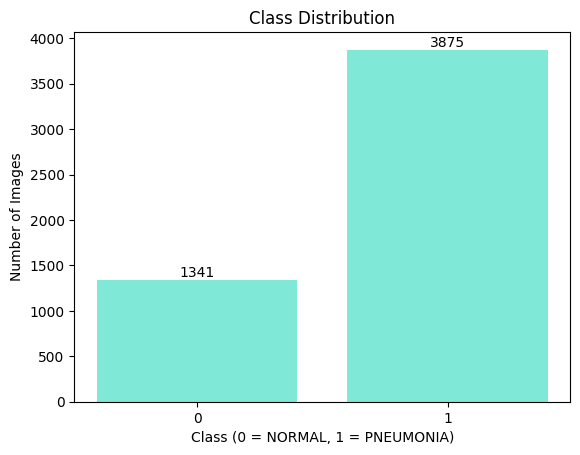

In [39]:
# ===== Check Class Imbalance =====

classes, counts = np.unique(y, return_counts=True)

plt.figure()

bars = plt.bar(classes.astype(str), counts, color="#7FE8D7")

plt.title("Class Distribution")
plt.xlabel("Class (0 = NORMAL, 1 = PNEUMONIA)")
plt.ylabel("Number of Images")

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom'
    )

plt.show()

In [41]:
# ===== Calculate Weights =====

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y),
    y=y)

class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y), class_weights_arr)}

print("Class Weights:", class_weight)

Class Weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [48]:
# ===== Build Model =====

# Base Model
model = Sequential()

model.add(Input(shape=X.shape[1:]))

# Augmentations
model.add(RandomRotation(0.05))
model.add(RandomZoom(0.10))
model.add(RandomTranslation(0.05, 0.05))
model.add(RandomContrast(0.10))

# Layer 1
model.add(Conv2D(64, (3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(Conv2D(64, (3,3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Single Vector
model.add(Flatten())

# Combine Knowledge
model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1))
model.add(Activation("sigmoid"))

# Compile Model
model.compile(loss = "binary_crossentropy",
              optimizer = "adam",
              metrics = ['accuracy'])

# Train Model
history = model.fit(
    X,
    y,
    batch_size=32,
    epochs=1,
    validation_split=0.1,
    class_weight=class_weight
)

# Save Model
model.save("CNN.keras")

147/147 ━━━━━━━━━━━━━━━━━━━━ 613s 4s/step - accuracy: 0.6892 - loss: 0.5576 - val_accuracy: 0.8448 - val_loss: 0.3527


In [52]:
# ===== Load Saved Model =====

cnn_model = load_model("CNN.keras")

In [60]:
# ===== Preparing Single Image =====

def prepare_image(filepath):
    IMAGE_SIZE = 224

    img_array = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    if img_array is None:
        raise ValueError(f"Could not read image: {filepath}")

    img_resized = cv2.resize(img_array, (IMAGE_SIZE, IMAGE_SIZE))
    img_normalized = img_resized / 255.0
    img_reshaped = img_normalized.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)

    return img_reshaped

In [75]:
# ===== Pick Random Test Image =====

# Normal
normal_test_path = test_dir + "/NORMAL"

random_image = random.choice(os.listdir(normal_test_path))

image_path_n = os.path.join(normal_test_path, random_image)

print(image_path_n)

# Pneumonia
pneumonia_test_path = test_dir + "/PNEUMONIA"

random_image = random.choice(os.listdir(pneumonia_test_path))

image_path_p = os.path.join(pneumonia_test_path, random_image)

print(image_path_p)

/content/chest_xray/chest_xray/test/NORMAL/NORMAL2-IM-0288-0001.jpeg
/content/chest_xray/chest_xray/test/PNEUMONIA/person130_bacteria_627.jpeg


In [78]:
# ===== Predict Test Image =====

# Normal
prediction_n = model.predict(prepare_image(image_path_n))
score_n = float(prediction_n[0][0])

if score_n > 0.5:
    label_n = "PNEUMONIA"
else:
    label_n = "NORMAL"

print(f"Prediction: {label_n}")
print(f"Pneumonia Probability: {score_n:.6f}")

# Pneumonia
prediction_p = model.predict(prepare_image(image_path_p))
score_p = float(prediction_p[0][0])

if score_p > 0.5:
    label_p = "PNEUMONIA"
else:
    label_p = "NORMAL"

print(f"Prediction: {label_p}")
print(f"Pneumonia Probability: {score_p:.6f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediction: NORMAL
Pneumonia Probability: 0.246038
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Prediction: PNEUMONIA
Pneumonia Probability: 0.949132


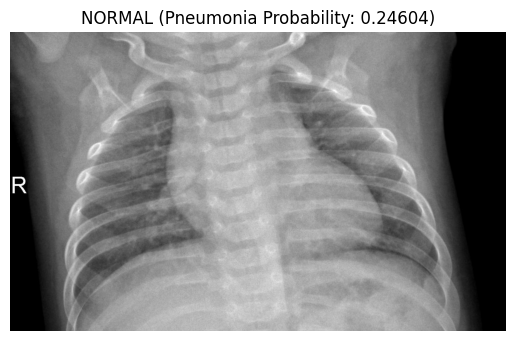

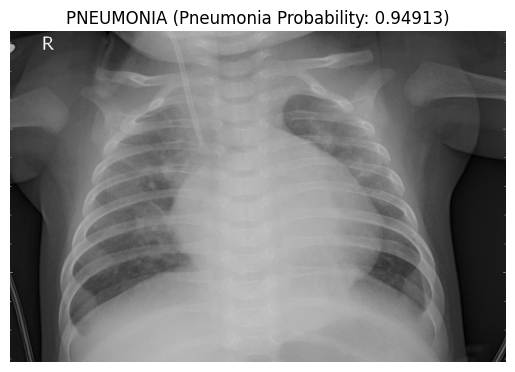

In [80]:
# ===== Output =====

# Normal
img = cv2.imread(image_path_n, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found")

plt.imshow(img, cmap="gray")
plt.title(f"{label_n} (Pneumonia Probability: {score_n:.5f})")
plt.axis("off")
plt.show()

# Pneumonia
img = cv2.imread(image_path_p, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found")

plt.imshow(img, cmap="gray")
plt.title(f"{label_p} (Pneumonia Probability: {score_p:.5f})")
plt.axis("off")
plt.show()

In [81]:
# ===== Create Test Set =====

test_data = []

def create_test_data():
    for category in CATEGORIES:
        path = os.path.join(test_dir, category)
        class_num = CATEGORIES.index(category)

        for image in os.listdir(path):
            try:
                img_path = os.path.join(path, image)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if img_array is None:
                    continue

                new_array = cv2.resize(img_array, (IMAGE_SIZE, IMAGE_SIZE))
                test_data.append([new_array, class_num])

            except Exception:
                pass

create_test_data()
print(len(test_data))

624


In [85]:
# ===== Shuffle Test Data =====

random.shuffle(test_data)

In [86]:
# ===== Create X and y Sets =====

X_test = []
y_test = []

for features, label in test_data:
    X_test.append(features)
    y_test.append(label)

X_test = np.array(X_test).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1)
y_test = np.array(y_test)

X_test = X_test / 255.0

In [89]:
# ===== Model Predictions =====

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


In [92]:
# ===== Confusion Matrix and Report =====

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred, target_names=CATEGORIES))

[[213  21]
 [ 83 307]]
              precision    recall  f1-score   support

      NORMAL       0.72      0.91      0.80       234
   PNEUMONIA       0.94      0.79      0.86       390

    accuracy                           0.83       624
   macro avg       0.83      0.85      0.83       624
weighted avg       0.85      0.83      0.84       624

